# Linear-Quadratic Mean-Field Control Problem with Affine Randomized Laws

Let $\mathcal{X} = \mathbb{R}, A = \mathbb{R}$. Assume $X_0 \sim \mathcal{\mu_0, \Sigma_0}$.

### State dynamics
Let $m_t = \mathbb{P}_{X_t^\theta}$. The controlled dynamics are $$X_{t+1} = aX_t + b\alpha_t + c\mathbb{E}_{m_t}[X] + \sigma \epsilon_{t+1}, \quad \epsilon_t \overset{\text{i.i.d.}}{\sim} \mathcal{N}(0, 1).$$ Equivalently, $$P_t(\cdot \mid x, \alpha, m) = \mathcal{N}(ax + b\alpha + c\bar{m}, \sigma^2),$$ where $\bar{m} = \int y\, m(dy)$.

### Gaussian policy class
For each $t$, $$\pi_t^\theta (\cdot \mid x, m) = \mathcal{N}(\theta_t^1 x + \theta_t^2 \bar{m}, \tau^2).$$ Hence $$\alpha_t = \theta_t^1 X_t + \theta_t^2 \bar{m}_t + \tau\eta_t, \quad \eta_t \sim \mathcal{N}(0,1).$$ The parameter is $$\theta = (\theta_t^1, \theta_t^2)_{t=0}^{T-1}.$$

### Randomization of the law
For each $t$, let $$U_t(x) = A_t x + B_t, \quad (A_t, B_t) \overset{\text{i.i.d.}}{\sim} \nu.$$ Define $$M_t^\lambda = (I_d + \lambda U_t)\sharp m_t.$$ Since $$(I + \lambda U_t)(x) = (1 + \lambda A_t)x + \lambda B_t,$$ we obtain $$M_t^\lambda = ((1 + \lambda A_t)I_d + \lambda B_t) \sharp m_t.$$

### Explicit form of the randomized law
Suppose $$m_t = \mathcal{N}(\mu_t, \Sigma_t).$$ Then $$M_t^\lambda = \mathcal{N}\big( (1+\lambda A_t)\mu_t + \lambda B_t, (1+\lambda A_t)^2 \Sigma_t \big).$$ Introduce $$\mu_t^\lambda = (1+\lambda A_t)\mu_t + \lambda B_t,$$ $$\Sigma_t^\lambda = (1+\lambda A_t)^2 \Sigma_t.$$ Then $$M_t^\lambda = \mathcal{N}(\mu_t^\lambda, \Sigma_t^\lambda).$$

### Perturbed policy
The policy receives the randomized measure: $$\alpha_t^\lambda \sim \pi_t^\theta (\cdot \mid X_t^\lambda, M_t^\lambda).$$ Since the policy only depends on the mean, $$\alpha_t^\lambda = \theta_t^1 X_t^\lambda + \theta_t^2 \mu_t^\lambda + \tau \eta_t.$$

### Perturbed dynamics
Substituting into the state equation gives $$X_{t+1}^\lambda = (a + b\theta_t^1)X_t^\lambda + (b \theta_t^2 + c)\mu_t^\lambda + b\tau \eta_t + \sigma \epsilon_{t+1}.$$ Using $$\mu_t^\lambda = (1 + \lambda A_t) \mu_t + \lambda B_t,$$ we obtain $$X_{t+1}^\lambda = (a+b\theta_t^1)X_t^\lambda + (b\theta_t^2 + c)\big( (1+ \lambda A_t) \mu_t + \lambda B_t \big) + b\tau \eta_t + \sigma \epsilon_{t+1}.$$ Conditionally on $(A_t, B_t)$, this is a linear Gaussian system.

### Evolution of the true law
Since everything is Gaussian, $$X_t^\lambda \sim \mathcal{N}(\mu_t, \Sigma_t)$$ for some deterministic moments satisfying $$\mu_{t+1} = (a + b\theta_t^1)\mu_t + (b\theta_t^2 + c) \mathbb{E}[\mu_t^\lambda].$$ But $$\mathbb{E}[\mu_t^\lambda] = \mu_t + \lambda \mathbb{E}[A_t]\mu_t + \lambda\mathbb{E}[B_t].$$ If $$\mathbb{E}[A_t] = \mathbb{E}[B_t] = 0,$$ then $$\mu_{t+1} = (a + b\theta_t^1 + b\theta_t^2 + c)\mu_t.$$ Similarly, $$\Sigma_{t+1} = (a + b\theta_t^1)^2 \Sigma_t + (b\theta\_t^2 + c)^2 \text{Var}(\mu_t^\lambda) + b^2 \tau^2 + \sigma^2.$$ Since $$\text{Var}(\mu_t^\lambda) = \lambda^2 \left( \mu_t^2 \text{Var}(A_t) + \text{Var}(B_t) + 2\mu_t \text{Cov}(A_t, B_t)\right),$$ the variance recursion is explicit.

### Cost functional
Take a standard LQ cost $$r_t (x, m, a) = qx^2 + ra^2 + \gamma(\bar{m})^2,$$ and terminal cost $$g(x, m) = q_T x^2 + \gamma_T (\bar{m})^2.$$ Replacing $m$ by $M_t^\lambda$, $$r_t(x, M_t^\lambda, a) = qx^2 + ra^2 + \gamma(\mu_t^\lambda)^2.$$ Hence $$J^\lambda (\theta) = \mathbb{E}\left[ \sum_{t=0}^{T-1} \big( q(X_t^\lambda)^2 + r(\alpha_t^\alpha)^2 + \gamma(\mu_t^\lambda)^2 \big) + q_T(X_T^\lambda)^2 + \gamma_T(\mu_T^\lambda)^2\right].$$ Since all variable are Gaussian, $$\mathbb{E}[(X_t^\lambda)^2] = \Sigma_t + \mu_t^2,$$ and $$\mathbb{E}[(\mu_t^\lambda)^2] = \mu_t^2 + \lambda^2 (\mu_t^2 \text{Var}(A_t) + \text{Var}(B_t) + 2\mu_t \text{Cov}(A_t, B_t)),$$ so $J^\lambda (\theta)$ admits a completely explicit closed-form expression.



In [19]:
import torch
import torch.optim as optim
from torch.distributions import Normal
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [20]:
# System parameters
T = 10                  # Time horizon
a, b, c = 1.0, 0.5, 0.2 # Dynamics coefficients
sigma = 0.1             # Environment noise std
tau = 0.1               # Policy noise std
mu_0 = 2.0              # Initial state mean
sigma_0 = 0.5           # Initial state std

# Cost parameters
q_cost = 1.0            # State cost
r_cost = 0.1            # Action cost
gamma_cost = 1.0        # Mean-field measure cost
q_T = 2.0               # Terminal state cost
gamma_T = 2.0           # Terminal mean-field measure cost

# Perturbation parameters
lambda_val = 0.5        # Perturbation scale
rho = 1.0               # Exogenous noise std

In [21]:
def simulate_trajectories(theta1, theta2, num_envs=1000):
    batch_size = num_envs

    log_probs_pi = torch.zeros((batch_size, T), device=device)
    log_probs_q = torch.zeros((batch_size, T), device=device)
    rewards = torch.zeros((batch_size, T), device=device)

    # Initialize states
    X_t = mu_0 + sigma_0 * torch.randn(batch_size, device=device)
    mu_t_theta = torch.tensor(mu_0, requires_grad=True, device=device)

    for t in range(T):
        # Measure perturbation
        dist_q = Normal(mu_t_theta, lambda_val * rho)
        m_bar_t = dist_q.sample((batch_size,))
        log_q_t = dist_q.log_prob(m_bar_t)
        log_probs_q[:, t] = log_q_t

        # Policy execution
        mean_pi_t = theta1[t] * X_t + theta2[t] * m_bar_t
        dist_pi = Normal(mean_pi_t, tau)
        alpha_t = dist_pi.sample()
        log_pi_t = dist_pi.log_prob(alpha_t)
        log_probs_pi[:, t] = log_pi_t

        # Environment step
        with torch.no_grad():
            epsilon_t = torch.randn(batch_size, device=device)
            X_next = a * X_t + b * alpha_t + c * m_bar_t + sigma * epsilon_t

            # Running cost
            cost_t = q_cost * (X_t**2) + r_cost * (alpha_t**2) + gamma_cost * (m_bar_t**2)
            rewards[:, t] = -cost_t

            X_t = X_next
        
        mu_t_theta = (a + b * theta1[t] + b * theta2[t] + c) * mu_t_theta

    # Terminal cost
    with torch.no_grad():
        terminal_cost = q_T * (X_t**2) + gamma_T * (m_bar_t**2)

    return log_probs_pi, log_probs_q, rewards, -terminal_cost

In [ ]:
# Learnable parameters
theta1 = torch.zeros(T, requires_grad=True, device=device)
theta2 = torch.zeros(T, requires_grad=True, device=device)

# Optimizer
optimizer = optim.Adam([theta1, theta2], lr=0.01)

epochs = 3000
batch_size = 2000
history_J = []

print("Starting training...")
for epoch in range(epochs):
    optimizer.zero_grad()

    # Rollout trajectories
    log_probs_pi, log_probs_q, rewards, terminal_cost = simulate_trajectories(theta1, theta2, num_envs=batch_size)

    # Compute returns
    returns = torch.zeros_like(rewards, device=device)
    G = terminal_cost
    for t in reversed(range(T)):
        G = rewards[:, t] + G
        returns[:, t] = G

    baseline = returns.mean(dim=0)
    returns_centered = returns - baseline

    # Compute score gradients
    returns_detached = returns_centered.detach()

    loss_pi = -(log_probs_pi * returns_detached).sum(dim=1).mean()
    loss_q = -(log_probs_q * returns_detached).sum(dim=1).mean()

    # Total objective
    total_loss = loss_pi + loss_q
    
    total_loss.backward()
    optimizer.step()

    true_J = -(rewards.sum(dim=1) + terminal_cost).mean().item()
    history_J.append(true_J)
    
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Total Expected Cost J(theta): {true_J:.4f}")


Starting training...
Epoch 50/3000 | Total Expected Cost J(theta): 60.6218
Epoch 100/3000 | Total Expected Cost J(theta): 37.9542
Epoch 150/3000 | Total Expected Cost J(theta): 29.4724
Epoch 200/3000 | Total Expected Cost J(theta): 24.4084
Epoch 250/3000 | Total Expected Cost J(theta): 21.8459
Epoch 300/3000 | Total Expected Cost J(theta): 19.8797
Epoch 350/3000 | Total Expected Cost J(theta): 18.2977
Epoch 400/3000 | Total Expected Cost J(theta): 16.9979
Epoch 450/3000 | Total Expected Cost J(theta): 16.2843
Epoch 500/3000 | Total Expected Cost J(theta): 15.8258
Epoch 550/3000 | Total Expected Cost J(theta): 15.4126
Epoch 600/3000 | Total Expected Cost J(theta): 15.1197
Epoch 650/3000 | Total Expected Cost J(theta): 14.9224
Epoch 700/3000 | Total Expected Cost J(theta): 14.6589
Epoch 750/3000 | Total Expected Cost J(theta): 14.6609
Epoch 800/3000 | Total Expected Cost J(theta): 14.1731
Epoch 850/3000 | Total Expected Cost J(theta): 14.2549
Epoch 900/3000 | Total Expected Cost J(theta)

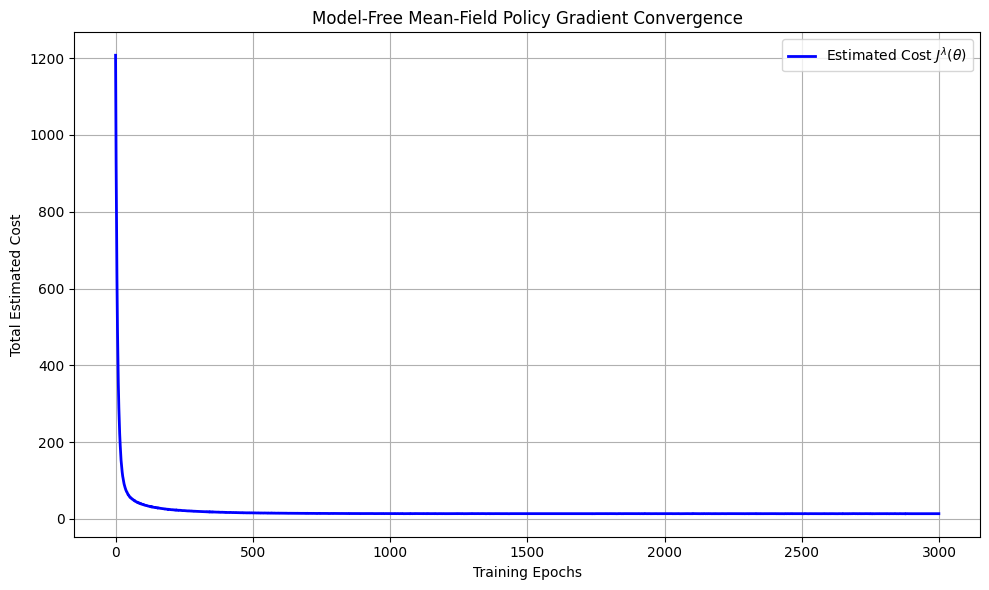

theta_1 (state gain): [-1.1998882  -0.86989504 -0.6334124  -0.55918854 -0.4963219  -0.4502503
 -0.419855   -0.44826582 -0.427351   -0.51257247]
theta_2 (mean gain): [-0.90269387 -0.6821097  -0.50189936 -0.4449245  -0.4070323  -0.36498037
 -0.34681526 -0.3572245  -0.32103074 -0.3255524 ]


In [23]:
plt.figure(figsize=(10, 6))
plt.plot(history_J, label='Estimated Cost $J^\\lambda(\\theta)$', color='blue', lw=2)
plt.title('Model-Free Mean-Field Policy Gradient Convergence')
plt.xlabel('Training Epochs')
plt.ylabel('Total Estimated Cost')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"theta_1 (state gain): {theta1.detach().cpu().numpy()}")
print(f"theta_2 (mean gain): {theta2.detach().cpu().numpy()}")